In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
H = 0.02        # gap between plates, m
U = 1.0         # top plate speed, m/s
nu = 1.5e-5     # kinematic viscosity (air), m^2/s
mu = 1.8e-5     # dynamic viscosity (air), Pa.s

N = 41                      # number of grid points across the gap
dy = H / (N - 1)
y = np.linspace(0, H, N)
t_diff = H**2 / nu          # diffusion timescale
print(f"dy = {dy:.6e} m, t_diff = {t_diff:.4f} s")

dy = 5.000000e-04 m, t_diff = 26.6667 s


In [4]:
def exact_solution(y, t, H, U, nu, n_terms=200):
    steady = U * y / H
    if t == 0:
        return np.zeros_like(y)
    transient = np.zeros_like(y)
    for n in range(1, n_terms + 1):
        term = ((-1)**n / n) * np.sin(n * np.pi * y / H) * \
               np.exp(-(n**2) * (np.pi**2) * nu * t / H**2)
        transient += term
    return steady + (2 * U / np.pi) * transient

In [5]:
def thomas_solve(a, b, c, d):
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        m = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / m
        dp[i] = (d[i] - a[i] * dp[i-1]) / m
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i+1]
    return x

In [6]:
def solve_ftcs(N, dy, dt, n_steps, U):
    u = np.zeros(N)
    u[-1] = U
    r = nu * dt / dy**2
    for _ in range(n_steps):
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0] = 0.0
        u_new[-1] = U
        u = u_new
    return u

In [7]:
def solve_btcs(N, dy, dt, n_steps, U):
    u = np.zeros(N)
    u[-1] = U
    r = nu * dt / dy**2
    n_int = N - 2

    a = -r * np.ones(n_int)
    b = (1 + 2*r) * np.ones(n_int)
    c = -r * np.ones(n_int)

    for _ in range(n_steps):
        d = u[1:-1].copy()
        d[0]  += r * 0.0
        d[-1] += r * U
        u_int = thomas_solve(a, b, c, d)
        u = np.concatenate(([0.0], u_int, [U]))
    return u

In [8]:
def solve_cn(N, dy, dt, n_steps, U):
    u = np.zeros(N)
    u[-1] = U
    r = nu * dt / dy**2
    n_int = N - 2

    a = -(r/2) * np.ones(n_int)
    b = (1 + r) * np.ones(n_int)
    c = -(r/2) * np.ones(n_int)

    for _ in range(n_steps):
        u_old = u.copy()
        d = (r/2)*u_old[0:-2] + (1-r)*u_old[1:-1] + (r/2)*u_old[2:]
        d[0]  += (r/2) * 0.0
        d[-1] += (r/2) * U
        u_int = thomas_solve(a, b, c, d)
        u = np.concatenate(([0.0], u_int, [U]))
    return u

In [ ]:
r_unstable = 0.55   # just above the 0.5 limit
dt_unstable = r_unstable * dy**2 / nu

t_report = 5.0
n_steps_report = int(t_report / dt_unstable)
u_ftcs_report = solve_ftcs(N, dy, dt_unstable, n_steps_report, U)
print(f"r = {r_unstable} (above the 0.5 explicit stability limit), t = {t_report}s")
print(f"FTCS  max|u| = {np.max(np.abs(u_ftcs_report)):.3e}  (should blow up)")

r = 0.55 (above the 0.5 explicit stability limit), t = 5.0s
FTCS  max|u| = 2.994e+39  (should blow up)


In [10]:
# Shorter run: growing oscillations still visible on a readable plot scale
t_test = 0.3
n_steps_test = int(t_test / dt_unstable)

u_ftcs_unstable = solve_ftcs(N, dy, dt_unstable, n_steps_test, U)
u_btcs_unstable = solve_btcs(N, dy, dt_unstable, n_steps_test, U)
u_cn_unstable   = solve_cn(N, dy, dt_unstable, n_steps_test, U)
u_exact_test    = exact_solution(y, t_test, H, U, nu)

print(f"At shorter t = {t_test}s (for plotting):")
print(f"FTCS  max|u| = {np.max(np.abs(u_ftcs_unstable)):.3e}  (already oscillating/growing)")
print(f"BTCS  max|u| = {np.max(np.abs(u_btcs_unstable)):.3e}  (should stay bounded, ~{U})")
print(f"CN    max|u| = {np.max(np.abs(u_cn_unstable)):.3e}  (should stay bounded, ~{U})")

At shorter t = 0.3s (for plotting):
FTCS  max|u| = 1.788e+00  (already oscillating/growing)
BTCS  max|u| = 1.000e+00  (should stay bounded, ~1.0)
CN    max|u| = 1.000e+00  (should stay bounded, ~1.0)


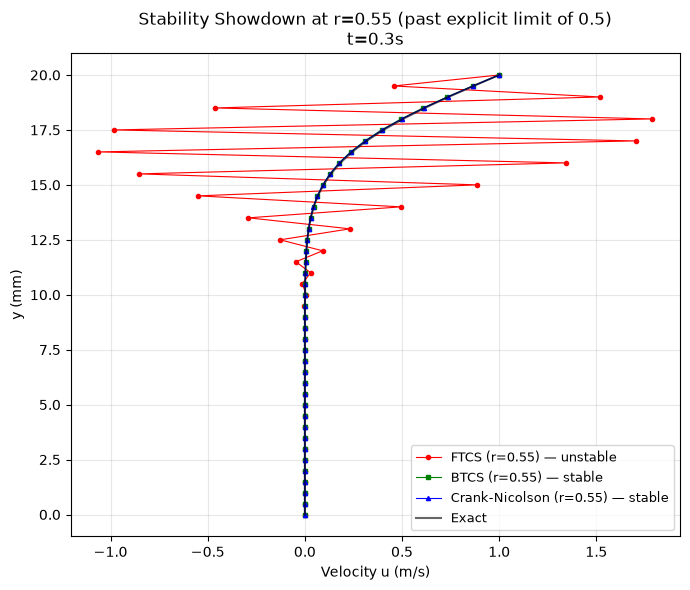

In [11]:
plt.figure(figsize=(7, 6))
plt.plot(u_ftcs_unstable, y*1000, 'ro-', markersize=3, linewidth=0.8, label=f'FTCS (r={r_unstable}) — unstable')
plt.plot(u_btcs_unstable, y*1000, 'gs-', markersize=3, linewidth=0.8, label=f'BTCS (r={r_unstable}) — stable')
plt.plot(u_cn_unstable, y*1000, 'b^-', markersize=3, linewidth=0.8, label=f'Crank-Nicolson (r={r_unstable}) — stable')
plt.plot(u_exact_test, y*1000, 'k-', linewidth=1.5, alpha=0.6, label='Exact')
plt.xlabel('Velocity u (m/s)')
plt.ylabel('y (mm)')
plt.title(f'Stability Showdown at r={r_unstable} (past explicit limit of 0.5)\nt={t_test}s')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stability_showdown.png', dpi=150)
plt.show()

In [ ]:
t_target = t_diff * 0.5   
u_exact_target = exact_solution(y, t_target, H, U, nu)

r_values_explicit = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]
dt_values_explicit = [r * dy**2 / nu for r in r_values_explicit]

r_values_implicit = [4.0, 2.0, 1.0, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]
dt_values_implicit = [r * dy**2 / nu for r in r_values_implicit]

In [13]:
errors_ftcs, dts_ftcs = [], []
for dt in dt_values_explicit:
    n_steps = round(t_target / dt)
    u_num = solve_ftcs(N, dy, dt, n_steps, U)
    errors_ftcs.append(np.max(np.abs(u_num - u_exact_target)))
    dts_ftcs.append(dt)

In [14]:
errors_btcs, dts_btcs = [], []
for dt in dt_values_implicit:
    n_steps = round(t_target / dt)
    u_num = solve_btcs(N, dy, dt, n_steps, U)
    errors_btcs.append(np.max(np.abs(u_num - u_exact_target)))
    dts_btcs.append(dt)

In [15]:
errors_cn, dts_cn = [], []
for dt in dt_values_implicit:
    n_steps = round(t_target / dt)
    u_num = solve_cn(N, dy, dt, n_steps, U)
    errors_cn.append(np.max(np.abs(u_num - u_exact_target)))
    dts_cn.append(dt)

In [16]:
print(f"{'r':>8} | {'dt (s)':>10} | {'BTCS err':>12} | {'CN err':>12}")
print("-" * 50)
for i, r in enumerate(r_values_implicit):
    print(f"{r:>8.2f} | {dts_btcs[i]:>10.4e} | {errors_btcs[i]:>12.4e} | {errors_cn[i]:>12.4e}")

       r |     dt (s) |     BTCS err |       CN err
--------------------------------------------------
    4.00 | 6.6667e-02 |   2.9216e-04 |   8.1200e-06
    2.00 | 3.3333e-02 |   1.4975e-04 |   8.9801e-06
    1.00 | 1.6667e-02 |   7.9265e-05 |   9.1952e-06
    0.50 | 8.3333e-03 |   4.4205e-05 |   9.2489e-06
    0.40 | 6.6667e-03 |   3.7208e-05 |   9.2554e-06
    0.30 | 5.0000e-03 |   2.7377e-05 |   6.4328e-06
    0.20 | 3.3333e-03 |   2.3228e-05 |   9.2640e-06
    0.10 | 1.6667e-03 |   1.6245e-05 |   9.2661e-06
    0.05 | 8.3333e-04 |   1.2755e-05 |   9.2667e-06


In [17]:
print(f"{'r':>8} | {'dt (s)':>10} | {'FTCS err':>12}")
print("-" * 38)
for i, r in enumerate(r_values_explicit):
    print(f"{r:>8.2f} | {dts_ftcs[i]:>10.4e} | {errors_ftcs[i]:>12.4e}")

       r |     dt (s) |     FTCS err
--------------------------------------
    0.50 | 8.3333e-03 |   3.2578e-05
    0.40 | 6.6667e-03 |   1.8596e-05
    0.30 | 5.0000e-03 |   1.4455e-05
    0.20 | 3.3333e-03 |   4.6744e-06
    0.10 | 1.6667e-03 |   2.2938e-06
    0.05 | 8.3333e-04 |   5.7797e-06


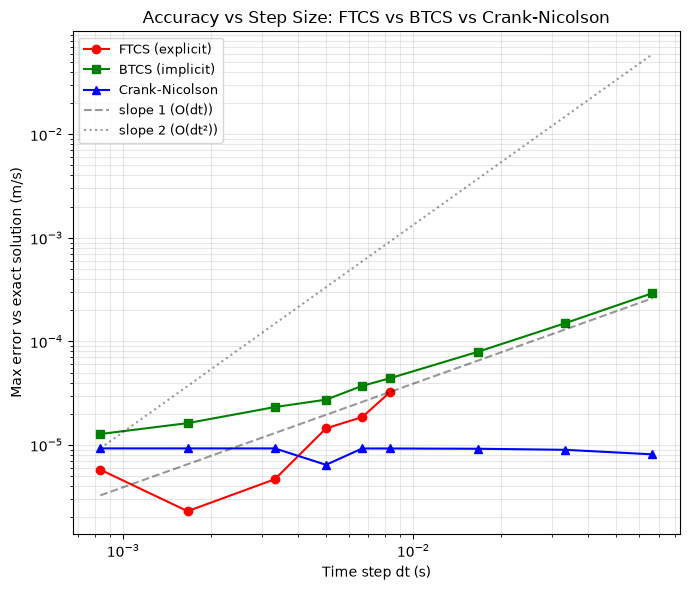

In [18]:
plt.figure(figsize=(7, 6))
plt.loglog(dts_ftcs, errors_ftcs, 'ro-', label='FTCS (explicit)', linewidth=1.5)
plt.loglog(dts_btcs, errors_btcs, 'gs-', label='BTCS (implicit)', linewidth=1.5)
plt.loglog(dts_cn, errors_cn, 'b^-', label='Crank-Nicolson', linewidth=1.5)

dt_arr = np.array(sorted(dts_btcs))
plt.loglog(dt_arr, errors_ftcs[0] * (dt_arr/dts_ftcs[0])**1, 'k--', alpha=0.4, label='slope 1 (O(dt))')
plt.loglog(dt_arr, errors_cn[-1] * (dt_arr/dts_cn[-1])**2, 'k:', alpha=0.4, label='slope 2 (O(dt²))')

plt.xlabel('Time step dt (s)')
plt.ylabel('Max error vs exact solution (m/s)')
plt.title('Accuracy vs Step Size: FTCS vs BTCS vs Crank-Nicolson')
plt.legend(fontsize=9)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('method_accuracy_comparison.png', dpi=150)
plt.show()